In [1]:
# ============================================================
# Author: Eugene Ablordppey
# SECTION 1: JPM Stock Direction Prediction using SVM
# Dataset: jpm_us_d.csv
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Load Data
data = pd.read_csv("jpm_us_d.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")
print("Dataset Shape:", data.shape)
print(data.head())

# Feature Engineering
data["Previous_Day_Return"] = data["Close"].pct_change()
data["MA_20"] = (data["Close"].rolling(20).mean())
data["Volatility"] = (data["Close"].pct_change().rolling(20).std())

def RSI(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0,0)
    loss = -delta.where(delta < 0,0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100-(100/(1+rs))

data["RSI"] = RSI(data["Close"])

# JPM daily return
data["Daily_Return"] = data["Close"].pct_change()

# Future return target
data["Future_Return"] = (data["Close"].shift(-1).pct_change())
data["Target"] = np.where(data["Future_Return"] > 0,1,0)
data.dropna(inplace=True)
print("\nFeature Engineered Dataset")
print(data.head())

# Features and Target
features = [
    "Previous_Day_Return",
    "Volume",
    "Volatility",
    "MA_20",
    "RSI",
    "Daily_Return"
]

X = data[features]
y = data["Target"]

# Train/Test Split (Chronological)
split = int(len(data)*0.80)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]
print("\nTraining Samples:",len(X_train))
print("Testing Samples:",len(X_test))

# SVM Pipeline
svm_model = Pipeline([
    ("scaler",StandardScaler()),
    ("svm",SVC(
        kernel="rbf",
        probability=True
    ))
])

# Hyperparameter Grid
parameter_grid = {
    "svm__C":[0.1,1,10,100,1000],
    "svm__gamma":[0.0001,0.001,0.01,0.1,1]
}

# Grid Search
grid_search = GridSearchCV(
    svm_model,
    parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train,y_train)

# Best Parameters
print("\nBest Parameters:")
print(grid_search.best_params_)
print("\nBest CV Accuracy:")
print(round(grid_search.best_score_,4))

# Final Model
best_model = grid_search.best_estimator_
pred = best_model.predict(
    X_test
)

print("\nTest Accuracy:")
print(round(accuracy_score(y_test,pred),4))
print("\nClassification Report:")
print(classification_report(y_test,pred))

# Grid Search Results
results = pd.DataFrame(grid_search.cv_results_)
results_table = results[
[
"param_svm__C",
"param_svm__gamma",
"mean_test_score"
]
].copy()

results_table.columns = [
"C",
"Gamma",
"Validation Accuracy"
]

results_table["Validation Accuracy (%)"] = (
    results_table["Validation Accuracy"]*100
)

results_table = results_table.sort_values(
    "Validation Accuracy (%)",
    ascending=False
)

print("\nTop Hyperparameter Results")
print(results_table.head(10))
results_table.to_csv(
"JPM_SVM_GridSearch_Results.csv",
index=False
)

# Fixed Gamma model for validation curve
best_gamma = grid_search.best_params_["svm__gamma"]
svm_fixed_gamma = Pipeline([
    ("scaler",StandardScaler()),
    ("svm",SVC(
        kernel="rbf",
        gamma=best_gamma
    ))
])

C:\Users\eyram\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Dataset Shape: (14159, 6)
        Date     Open     High      Low    Close         Volume
0 1970-01-02  2.70388  2.70388  2.67490  2.70388   34041.702124
1 1970-01-05  2.70388  2.71076  2.68216  2.70388   44440.279714
2 1970-01-06  2.70388  2.73246  2.68934  2.73246   38772.769923
3 1970-01-07  2.73984  2.81165  2.73984  2.79730  102129.177859
4 1970-01-08  2.79014  2.79014  2.75438  2.79014   30260.308649

Feature Engineered Dataset
         Date     Open     High      Low    Close        Volume  \
20 1970-01-30  2.53794  2.58127  2.53794  2.58127  40661.939853   
21 1970-02-02  2.55946  2.55946  2.55946  2.55946   9458.064111   
22 1970-02-03  2.55946  2.61703  2.55228  2.61035  31204.893614   
23 1970-02-04  2.61035  2.67490  2.61035  2.61035  57687.880274   
24 1970-02-05  2.61035  2.63118  2.58127  2.61703  36876.474891   

    Previous_Day_Return     MA_20  Volatility        RSI  Daily_Return  \
20             0.017073  2.722058    0.015885  26.441806      0.017073   
21         

Top Hyperparameter Combinations


,C,Gamma,Validation Accuracy,Validation Accuracy (%)
0,0.1,0.0001,0.540801,54.080098
1,0.1,0.001,0.540801,54.080098
5,1,0.0001,0.540094,54.009365
16,100,0.001,0.528511,52.851097
7,1,0.01,0.528423,52.842256
2,0.1,0.01,0.526477,52.647738
11,10,0.001,0.525770,52.577004
15,100,0.0001,0.525063,52.506270
20,1000,0.0001,0.524886,52.488586
6,1,0.001,0.524709,52.470903


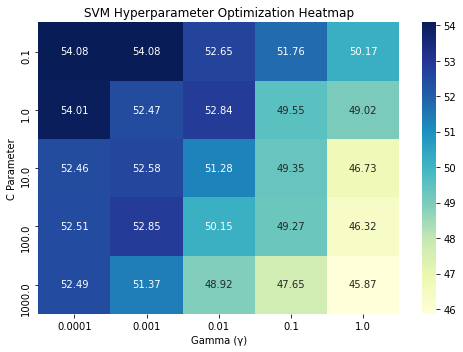

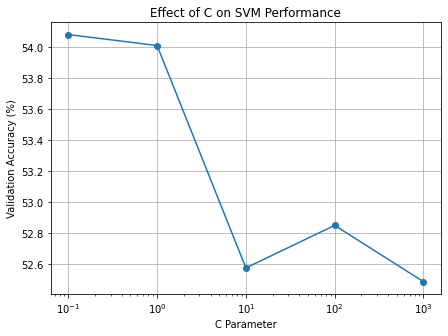

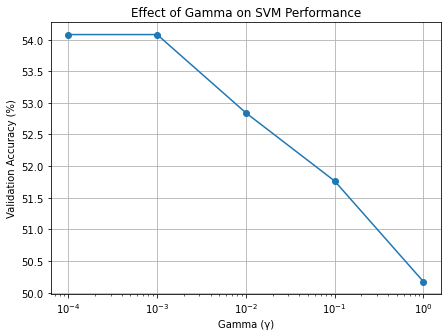

Section 2 completed successfully


In [2]:
# SVM Hyperparameter Optimization Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Grid Search Results Table
print("Top Hyperparameter Combinations")
display(results_table.head(10))

# Hyperparameter Heatmap
heatmap = results.pivot_table(index="param_svm__C",columns="param_svm__gamma",values="mean_test_score")
plt.figure(figsize=(7,5))
sns.heatmap(heatmap*100,annot=True,fmt=".2f",cmap="YlGnBu")
plt.title("SVM Hyperparameter Optimization Heatmap")
plt.xlabel("Gamma (γ)")
plt.ylabel("C Parameter")
plt.tight_layout()
plt.show()

# Effect of C
C_plot = (results_table.groupby("C")["Validation Accuracy (%)"].max())
plt.figure(figsize=(7,5))
plt.plot(C_plot.index,C_plot.values,marker="o")
plt.xscale("log")
plt.xlabel("C Parameter")
plt.ylabel("Validation Accuracy (%)")
plt.title("Effect of C on SVM Performance")
plt.grid()
plt.show()

# Effect of Gamma
Gamma_plot = (results_table.groupby("Gamma")["Validation Accuracy (%)"].max())
plt.figure(figsize=(7,5))
plt.plot(Gamma_plot.index,Gamma_plot.values,marker="o")
plt.xscale("log")
plt.xlabel("Gamma (γ)")
plt.ylabel("Validation Accuracy (%)")
plt.title("Effect of Gamma on SVM Performance")
plt.grid()
plt.show()